In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import List, Dict
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *

#### Plot markup settting

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

### Data container

In [4]:
data_records = load_all_experiments("data")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data/c0")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [7]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


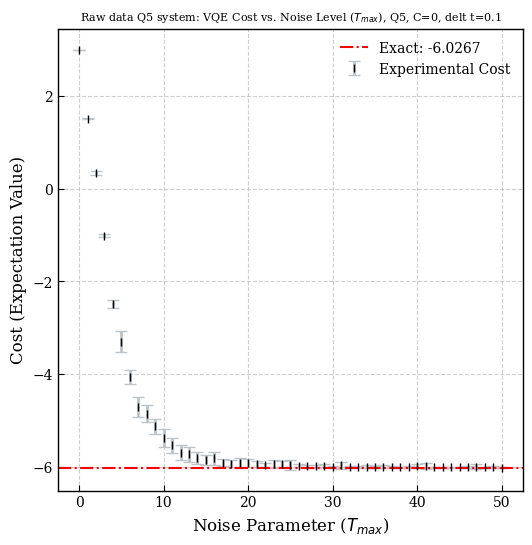

In [8]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

### $n$ from noise-free $C=0$ in $T_{max}$ range [0, 30]

In [9]:
# Noiseless guesses
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0
T0_GUESS_NOISELESS = 8.0

In [10]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""
mask = 31
t = noise_levels_c0[:mask]          # T_max
y = vqe_means_c0[:mask]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:mask]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]

# Guesses for noise-free data hill fitting
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0

T0_GUESS_NOISELESS = 8.0
p0 = [ZNE_GUESS_NOISELESS, A0_GUESS_NOISELESS, T0_GUESS_NOISELESS]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

fit_results = {}
for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    # Store results in dictionary
    fit_results[n] = {
        "initial_guess": {"ZNE0": p0[0], "A0_0": p0[1], "T0_0": p0[2]},
        "params": {"ZNE": ZNE, "A0": A0, "T0": T0},
        "LS": LS_red,
    }
# --- Print Summary Table ---
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.8104 |   10.8439 |     5.07 |   33.802
 2 |    -5.000 |    10.000 |     8.00 ||   -6.0875 |    9.0206 |     3.04 |   25.351
 3 |    -5.000 |    10.000 |     8.00 ||   -5.9365 |    8.7690 |     2.98 |   88.591
 4 |    -5.000 |    10.000 |     8.00 ||   -5.9073 |    8.6807 |     3.03 |  138.008
 5 |    -5.000 |    10.000 |     8.00 ||   -5.8952 |    8.6358 |     3.07 |  172.480
 6 |    -5.000 |    10.000 |     8.00 ||   -5.8876 |    8.6075 |     3.09 |  197.901
 7 |    -5.000 |    10.000 |     8.00 ||   -5.8811 |    8.5875 |     3.10 |  217.025
 8 |    -5.000 |    10.000 |     8.00 ||   -5.8746 |    8.5723 |     3.10 |  231.458
 9 |    -5.000 |   

In [11]:
BEST_n_FROM_C0  = 2
######################################################################
BEST_T0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["T0"]
BEST_A0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["A0"]
ZNE_c0_best = fit_results[BEST_n_FROM_C0]["params"]["ZNE"]
E_mix   = 0.0   # Tr(H_Ising) = 0

lsf_record_c0 = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "lsf": fit_results,
    "bests": {
        "n": BEST_n_FROM_C0,
        "A": BEST_A0_FROM_C0,
        "T0": BEST_T0_FROM_C0,
        "ZNE": ZNE_c0_best,
    }
}
print(f"Best n = {BEST_n_FROM_C0}")
print(f"BEST_T0_FROM_C0 = {BEST_T0_FROM_C0}")
print(f"BEST_A0_FROM_C0 = {BEST_A0_FROM_C0}")
print(f"ZNE_c0_best = {ZNE_c0_best}")

Best n = 2
BEST_T0_FROM_C0 = 3.042397899782802
BEST_A0_FROM_C0 = 9.02055870884778
ZNE_c0_best = -6.087516684866581


---

##  Noisy LSF with $C$=0.01

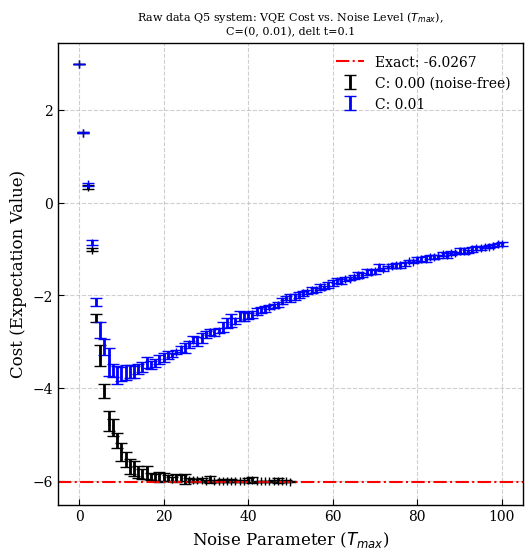

In [12]:
# Extracting components
vqe_means_c0_01 = data_records["c0.01"]["processed"]["vqe_means"]
vqe_stds_c0_01 = data_records["c0.01"]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records["c0.01"]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='black', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels_c0_01, vqe_means_c0_01, yerr=vqe_stds_c0_01, fmt='|', color='blue', 
             ecolor='blue', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.01')
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$),\nC=(0, 0.01), delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

#### $\gamma$ from large $T_{max} = [50, 100]$

$$f_{\text{noisy}}(t) = B \cdot e^{-\gamma t}, \quad t \in [50, 100]$$

In [13]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][-mask:]
y = rec["processed"]["vqe_means"][-mask:]
sigma = rec["processed"]["vqe_stds"][-mask:]

# =========================
# Initial guesses and bounds
# Model: f(t) = B * exp(-gamma * t)
# Parameter order: [gamma, B]
# =========================
B_guess = BEST_A0_FROM_C0 + ZNE_c0_best
p0 = [
    0.05,      # gamma: slow decay at large-t
    B_guess,      # B: first point in large-t window
]

bounds = (
    [1e-6, -np.inf],   # gamma > 0, B free
    [1.0,   np.inf],   # gamma not too large (stiff), B free
)

# =========================
# Call the fitter
# =========================
result_fit_gamma_largeT = fit_gamma_largeT(
    t=t,
    y=y,
    sigma=sigma,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =========================
# Extract results
# =========================
popt = result_fit_gamma_largeT["output"]["popt"]
pcov = result_fit_gamma_largeT["output"]["pcov"]

gamma_fit, B_fit = popt

GAMMA_FROM_LARGE_T = gamma_fit
B_FROM_LARGE_T     = B_fit

# =========================
# Clean summary table
# =========================
print(f"\nLarge-T Exponential Fit: f(t) = B · exp(−γ t) with T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'B':>6} | {p0[1]:12.4e} | {B_fit:12.4e}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0635e+04                                    2.28e+05    
       1              2         2.7113e+04      3.52e+03       2.93e+00       2.82e-02    
       2              3         2.7113e+04      1.68e-04       7.30e-01       2.81e-04    
       3              4         2.7113e+04      5.37e-03       1.13e-01       7.51e-02    
       4              5         2.6904e+04      2.09e+02       1.93e-01       9.58e+02    
       5              6         1.6465e+03      2.53e+04       6.91e-01       5.04e+03    
       6              7         7.6364e+02      8.83e+02       4.07e-01       6.44e+04    
       7              9         5.1415e+02      2.49e+02       3.67e-01       9.97e+02    
       8             10         2.3252e+02      2.82e+02       7.32e-01       1.43e+03    
       9             11         6.7217e+01      1.65e+02       7.38e-01       9.28e+02    

#### $(ZNE, A, T_0)$ from small $T_{max}=[0, 5]$

$$f_{\text{noisy}}(t) = ZNE + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \text{ where} \quad t \in [0, 5]$$

In [14]:
# =========================
# Data selection (large-t window)
# =========================
mask = 6
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    ZNE_GUESS_NOISELESS, # ZNE from noise less c=0
    A0_GUESS_NOISELESS,     # A from noiseless c=0
    T0_GUESS_NOISELESS,     # T0 from noiseless c=0
]

bounds = (
    [-10.0,   0.0,  0], # lower [ ZNE, A, T0 ]
    [ 0., 200.0, 10],   # upper [ ZNE, A, T0 ]
)

result_fit_in_smallT = fit_smallT_ZNE(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n_FROM_C0,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================

popt = result_fit_in_smallT["output"]["popt"]
pcov = result_fit_in_smallT["output"]["pcov"]

ZNE_fit, A_fit, T0_fit = popt

ZNE_FROM_NOISY_SMALL_T = ZNE_fit
A_FROM_NOISY_SMALL_T   = A_fit
T0_FROM_NOISY_SMALL_T  = T0_fit

print(f"\nSmall-T Hill Fit:  f(t) = ZNE + A / (1 + (t/T0)^n) with n=2, T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'ZNE':>6} | {p0[0]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[1]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[2]:12.4f} | {T0_fit:12.4f}")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3506e+14                                    4.35e+15    
       1              2         6.0216e+12      4.29e+14       3.74e+00       4.52e+14    
       2              3         1.8372e+09      6.02e+12       1.82e+00       7.75e+12    
       3              4         1.2547e+03      1.84e+09       2.86e-01       2.45e+09    
       4              5         1.0653e+03      1.89e+02       2.72e-02       1.29e+03    
       5              6         2.9221e+02      7.73e+02       3.76e+00       4.47e+03    
       6              7         1.7771e+02      1.15e+02       6.31e-01       3.10e+02    
       7              8         1.4298e+02      3.47e+01       6.94e-01       3.30e+02    
       8              9         1.4163e+02      1.35e+00       1.22e-01       1.68e+01    
       9             10         1.4161e+02      2.15e-02       1.73e-02       1.53e+00    

---

In [15]:
print("All fitted parameters:")
print("****************************")
print(f"GAMMA_FROM_LARGE_T = {GAMMA_FROM_LARGE_T}")
print(f"B_FROM_LARGE_T = {B_FROM_LARGE_T}")
print(f"ZNE_FROM_NOISY_SMALL_T = {ZNE_FROM_NOISY_SMALL_T}")
print(f"A_FROM_NOISY_SMALL_T = {A_FROM_NOISY_SMALL_T}")
print(f"T0_FROM_NOISY_SMALL_T = {T0_FROM_NOISY_SMALL_T}")
print("****************************")   
print("End of fitted parameters.")

All fitted parameters:
****************************
GAMMA_FROM_LARGE_T = 0.016757638541062304
B_FROM_LARGE_T = -4.758846539294926
ZNE_FROM_NOISY_SMALL_T = -2.0177814739005315
A_FROM_NOISY_SMALL_T = 5.017781548473394
T0_FROM_NOISY_SMALL_T = 1.5547854398013081
****************************
End of fitted parameters.


---

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right], \quad q=0.7 \text{ for } C=0.01$$

In [16]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}, q=0.7$"

#### Whole system fitting in $T_{max}=[0, 50]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   5.1099e-02 |   1.3092e-03 | 2.56e-02
   ZNE |  -2.0178e+00 |  -4.8818e+00 |   7.0869e-02 | 1.45e-02
     A |   5.0178e+00 |   7.8818e+00 |   7.0869e-02 | 8.99e-03
    T0 |   1.5548e+00 |   2.2520e+00 |   1.7980e-02 | 7.98e-03


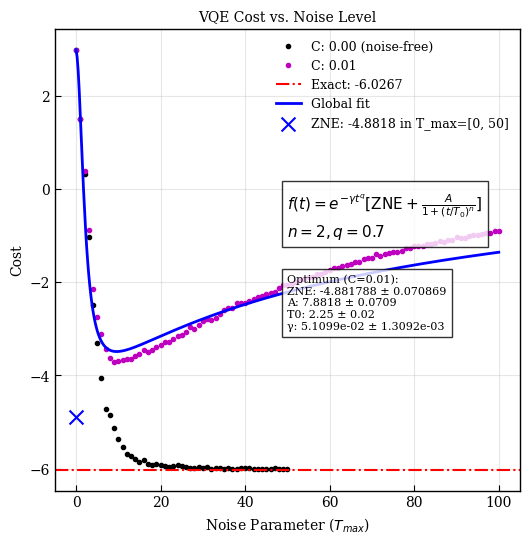

In [17]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0
q=0.7
# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

#### Whole system fitting in $T_{max}=[0, 100]$


Fit Results (n=2):
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   7.2291e-02 |   5.2656e-04 | 7.28e-03
   ZNE |  -2.0178e+00 |  -6.0536e+00 |   5.1227e-02 | 8.46e-03
     A |   5.0178e+00 |   9.0536e+00 |   5.1227e-02 | 5.66e-03
    T0 |   1.5548e+00 |   2.5267e+00 |   1.4468e-02 | 5.73e-03


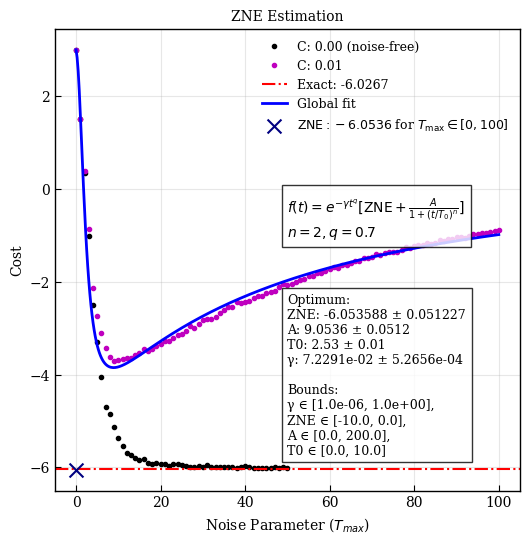

In [18]:
# --- Configuration & Parameters ---
mask_idx = 101
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(
    0, ZNE_fit, 
    color="#000080", marker="x", s=100, zorder=5, 
    label=rf"$\text{{ZNE}}: {ZNE_fit:.4f}$ for $T_{{\max}} \in [0, {mask_idx-1}]$"
)

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}]"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.08, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.title("ZNE Estimation", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

---

#### Optimizing $q$ test

Fitting parameters $(\gamma, ZNE, A, T_0, q)$

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$

In [19]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}$"


Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   7.2291e-02 |   5.1099e-02 |   2.4200e-02 | 4.74e-01
   ZNE |  -6.0536e+00 |  -4.8818e+00 |   3.7925e-01 | 7.77e-02
     A |   9.0536e+00 |   7.8818e+00 |   3.7925e-01 | 4.81e-02
    T0 |   2.5267e+00 |   2.2520e+00 |   1.0565e-01 | 4.69e-02
     q |   8.0000e-01 |   7.0000e-01 |   9.7458e-02 | 1.39e-01


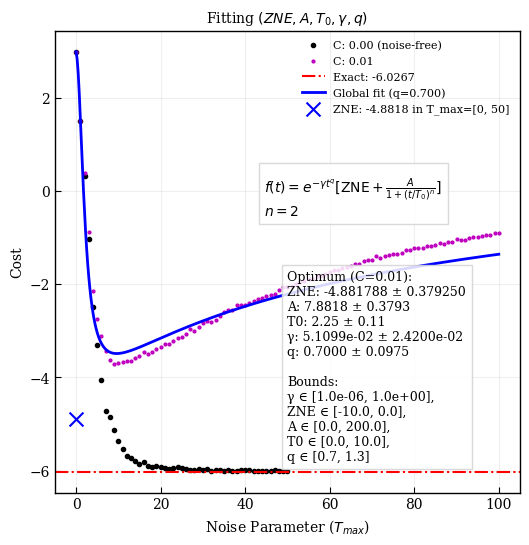

In [20]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0, q]
# p0 uses your carefully crafted variables with q initialized at 1.0
p0 = [
    gamma_fit, ZNE_fit, A_fit, T0_fit,
    0.8
]

bounds = (
    [1e-6, -10.0, 0.0, 0, 0.7], # Lower
    [1.0, 0.0, 200.0, 10, 1.3]   # Upper (constrained q to +10%)
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
# Note: Using your updated function name fit_fq_noisy
result_global = fit_fq_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors from covariance matrix
perr = np.sqrt(np.diag(pcov))

# Unpacking results
gamma_fit, ZNE_fit, A_fit, T0_fit, q_fit = popt
gamma_err, ZNE_err, A_err, T0_err, q_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params_names = ['gamma', 'ZNE', 'A', 'T0', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
# Cleaned up model to work correctly with *popt unpacking
def f_noisy_model(t, g, z, a, t0, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
# This now correctly passes (t_grid, gamma, ZNE, A, T0, q_fit)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"Global fit (q={q_fit:.3f})")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q: {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}], \nq ∈ [{bounds[0][4]:.1f}, {bounds[1][4]:.1f}]"
)

# Placed boxes in a clear area (middle-right)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(0.5, 0.07, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

plt.title("Fitting $(ZNE, A, T_0, \gamma, q)$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()

---

#### Whole system re-fitting in $T_{max}=[10, 40]$ using optimums in $T_{max}=[0, 100]$



Fit Results for Window [10:41] (n=2):
 Param |      Initial |       Fitted | Rel. Error
--------------------------------------------------------------
 gamma |   5.1099e-02 |   1.8518e-02 | 1.83e-01
   ZNE |  -4.8818e+00 |  -5.1454e+00 | 1.57e-01
     A |   7.8818e+00 |   1.4417e+00 | 8.83e-01
    T0 |   2.2520e+00 |   1.0000e+01 | 1.52e+00


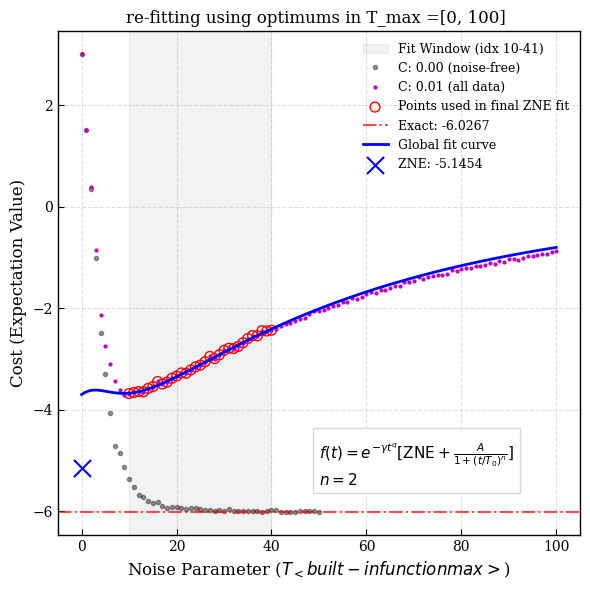

In [21]:
# =====================================================
# 1. Configuration & Parameters
# =====================================================
mask_idx = 41              # Upper bound index
start_idx = 10             # Lower bound index
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses: Using your previous fit results as the starting point
# [gamma, ZNE, A, T0]
p0 = [GAMMA_FROM_LARGE_T, ZNE_FROM_NOISY_SMALL_T, A_FROM_NOISY_SMALL_T, T0_FROM_NOISY_SMALL_T]
p0_from_entire_range = [gamma_fit, ZNE_fit, A_fit, T0_fit]
bounds = ([1e-6, -10.0, 0.0, 0], [1, 0., 200.0, 10])

# =====================================================
# 2. Data Extraction (Slicing the window)
# =====================================================
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][start_idx:mask_idx]
y_data = rec["processed"]["vqe_means"][start_idx:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][start_idx:mask_idx]

# =====================================================
# 3. Execution: Global Fit
# =====================================================
result_global = fit_f_noisy(
    t=t_data, 
    y=y_data, 
    sigma=sigma_data, 
    n=n_exponent,
    p0=p0_from_entire_range, 
    bounds=bounds, 
    method="trf", 
    ftol=1e-12, 
    xtol=1e-12, 
    gtol=1e-12,
    verbose=0
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]
gamma_fit, ZNE_fit, A_fit, T0_fit = popt

# --- Print Summary Table ---
print(f"\nFit Results for Window [{start_idx}:{mask_idx}] (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Rel. Error'}")
print("-" * 62)
params_names = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params_names):
    rel_err = np.sqrt(pcov[i,i]) / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0_from_entire_range[i]:12.4e} | {popt[i]:12.4e} | {rel_err:.2e}")

# =====================================================
# 4. Visualization
# =====================================================
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * t) * (z + a / (1.0 + (t / t0) ** n))

# Generate smooth curve for plotting
t_grid = np.linspace(0, max(noise_levels_c0_01), 400)
y_fit_curve = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# A. Highlight the "Masked" Data Range
t_min_window = rec["processed"]["t_max"][start_idx]
t_max_window = rec["processed"]["t_max"][mask_idx-1]
plt.axvspan(t_min_window, t_max_window, color='gray', alpha=0.1, label=f'Fit Window (idx {start_idx}-{mask_idx})')

# B. Plot all data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.4, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01 (all data)")

# C. Highlight specific points used in this fit
plt.scatter(t_data, y_data, facecolors='none', edgecolors='red', s=50, linewidth=1, label='Points used in final ZNE fit')

# D. Plot exact solution and ZNE result
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", alpha=0.7, label=f"Exact: {EXACT_SOLUTION:.4f}")
plt.plot(t_grid, y_fit_curve, color="blue", lw=2, label="Global fit curve")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=150, zorder=5, label=f"ZNE: {ZNE_fit:.4f}")

# E. Annotation & Styling
eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.1, eq_text, transform=plt.gca().transAxes, fontsize=11, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray'))
plt.title(f"re-fitting using optimums in T_max =[0, 100] ", fontsize=12)
plt.xlabel(f"Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, framealpha=1)

plt.tight_layout()
plt.show()

In [22]:
lsf_fit_gamma_largeT = {
    "name": "fit_gamma_largeT",
    "model": "exp(-gamma t) * B",
    "result": result_fit_gamma_largeT,
}

lsf_fit_in_smallT = {
    "name": "fit_in_smallT",
    "model": "ZNE + A / (1 + (t/T0)^n)",
    "result": result_fit_in_smallT,
}

lsf_fit_global = {
    "name": "fit_global",
    "model": "exp(-gamma t) * (ZNE + A / (1 + (t/T0)^n))",
    "result": result_global,
}
gamma_noisy_opt = lsf_fit_global["result"]["output"]["popt"][0]
ZNE_noisy_opt = lsf_fit_global["result"]["output"]["popt"][1]
A_noisy_opt = lsf_fit_global["result"]["output"]["popt"][2]
T0_noisy_opt = lsf_fit_global["result"]["output"]["popt"][3]

print("\nFinal optimized parameters from global fit:")
print(f"  gamma: {gamma_noisy_opt:.6e}")
print(f"  ZNE  : {ZNE_noisy_opt:.6f}")
print(f"  A    : {A_noisy_opt:.6f}")
print(f"  T0   : {T0_noisy_opt:.6f}")


Final optimized parameters from global fit:
  gamma: 1.851798e-02
  ZNE  : -5.145381
  A    : 1.441737
  T0   : 10.000000


---

### Fitting $\gamma, q$ with fixed parameters (ZNE, A, T0, n)

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.0042e-01 |   3.3838e-03 | 3.37e-02
     q |   8.0000e-01 |   6.0001e-01 |   9.6406e-03 | 1.61e-02


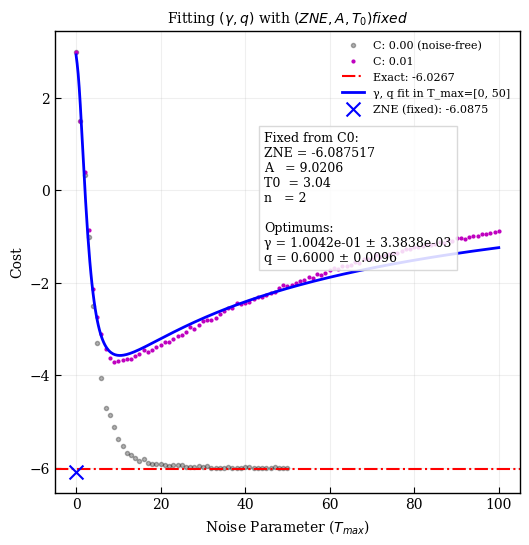

In [23]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03


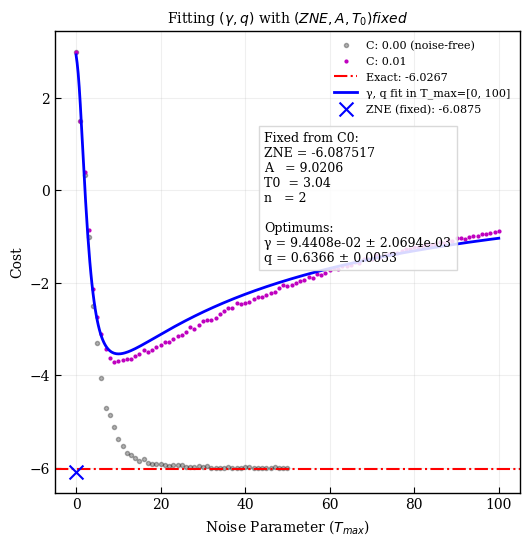

In [24]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.3790e-01 |   4.4817e-03 | 3.25e-02
     q |   8.0000e-01 |   5.0000e-01 |   1.0901e-02 | 2.18e-02


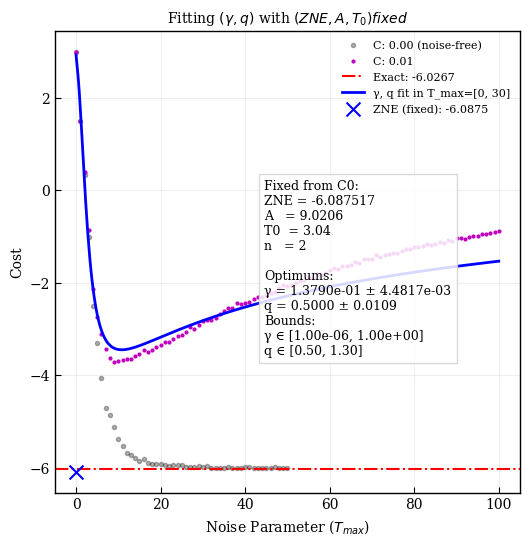

In [25]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.4262e-01 |   3.9282e-03 | 2.75e-02
     q |   8.0000e-01 |   5.0000e-01 |   7.9413e-03 | 1.59e-02


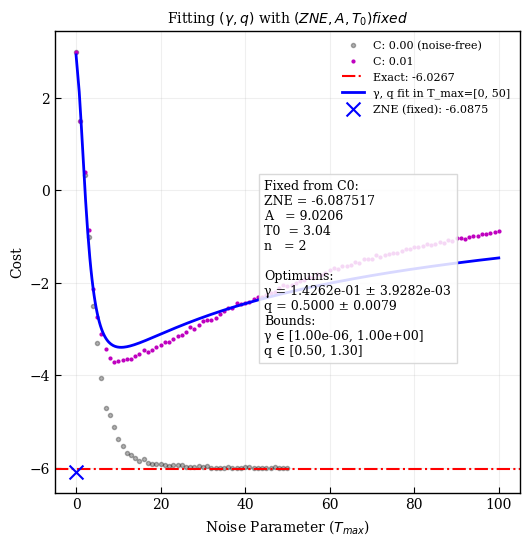

In [26]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03


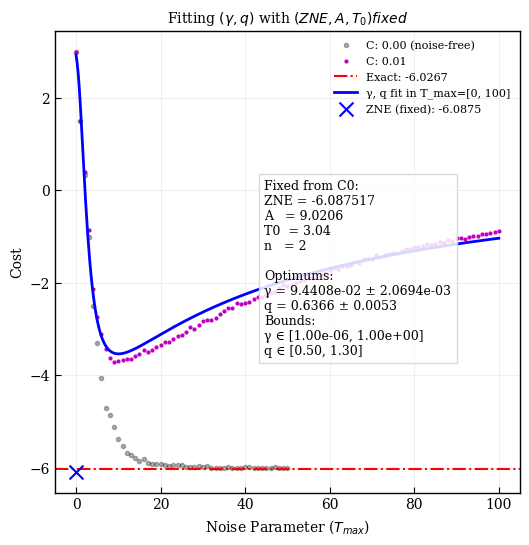

In [27]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


Dtailed pottting


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.3790e-01 |   4.4817e-03 | 3.25e-02
     q |   8.0000e-01 |   5.0000e-01 |   1.0901e-02 | 2.18e-02

Reduced chi-square = 33630032047.9030 (dof = 29)


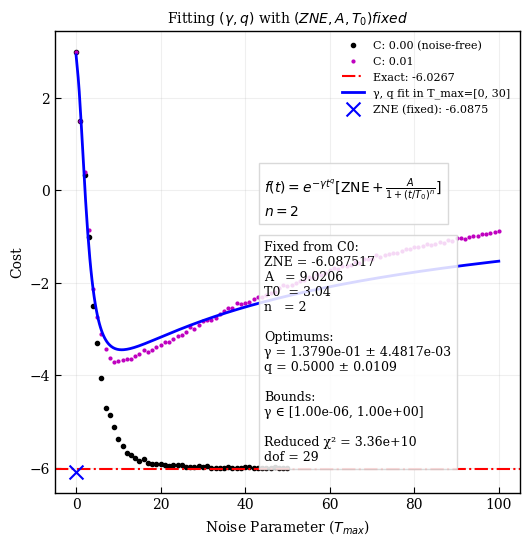

In [28]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.4262e-01 |   3.9282e-03 | 2.75e-02
     q |   8.0000e-01 |   5.0000e-01 |   7.9413e-03 | 1.59e-02

Reduced chi-square = 19903488355.9619 (dof = 49)


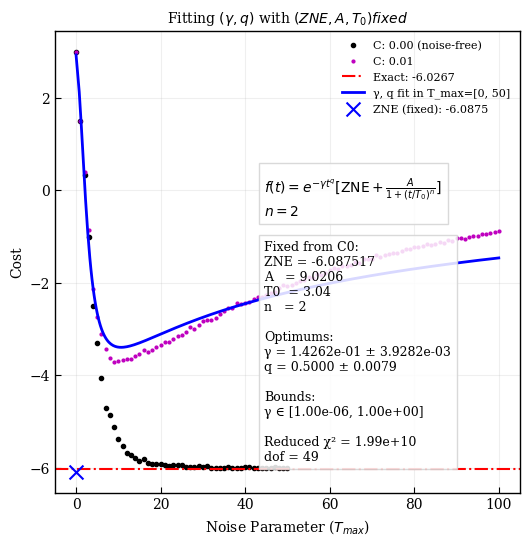

In [29]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   9.4408e-02 |   2.0694e-03 | 2.19e-02
     q |   8.0000e-01 |   6.3662e-01 |   5.2855e-03 | 8.30e-03

Reduced chi-square = 9851221520.7459 (dof = 99)


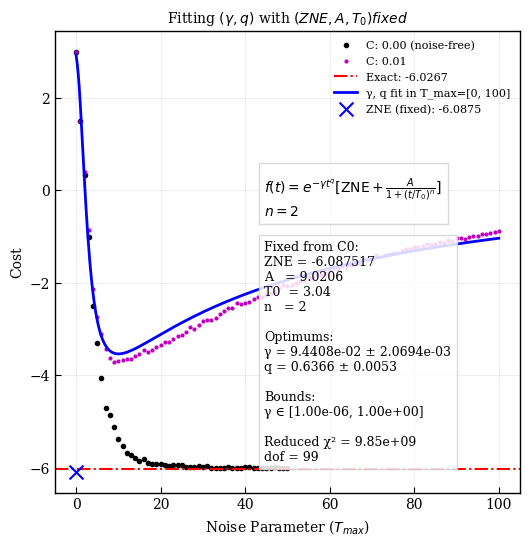

In [30]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


setting std = [1] and reduced xi


Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   1.0362e-01 |   8.4242e-02 | 8.13e-01
     q |   8.0000e-01 |   5.6897e-01 |   2.7441e-01 | 4.82e-01

Reduced chi-square = 0.0134 (dof = 29)


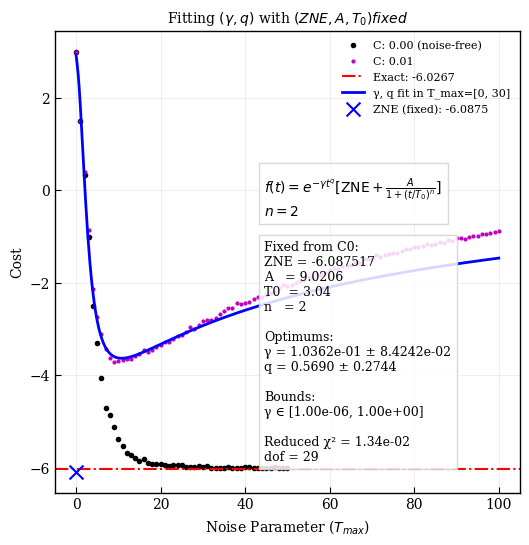

In [31]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   8.4262e-02 |   4.5837e-02 | 5.44e-01
     q |   8.0000e-01 |   6.4336e-01 |   1.6036e-01 | 2.49e-01

Reduced chi-square = 0.0103 (dof = 49)


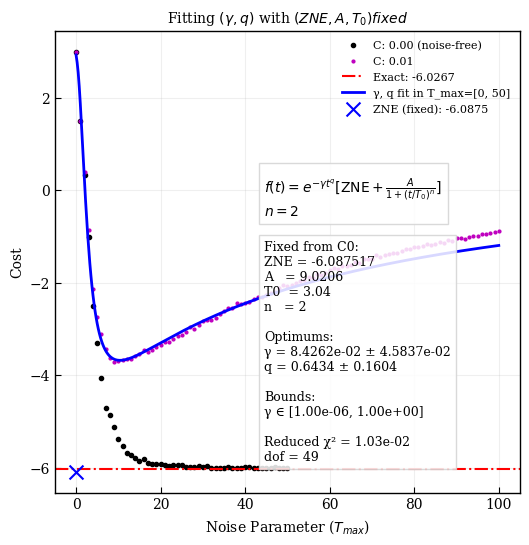

In [32]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()



Gamma–q Fit Results (n=2), T_max=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 Param |      Initial |       Fitted |        Error | Rel. Error
---------------------------------------------------------------------------
 gamma |   1.6758e-02 |   6.4877e-02 |   2.2928e-02 | 3.53e-01
     q |   8.0000e-01 |   7.2473e-01 |   9.0470e-02 | 1.25e-01

Reduced chi-square = 0.0091 (dof = 99)


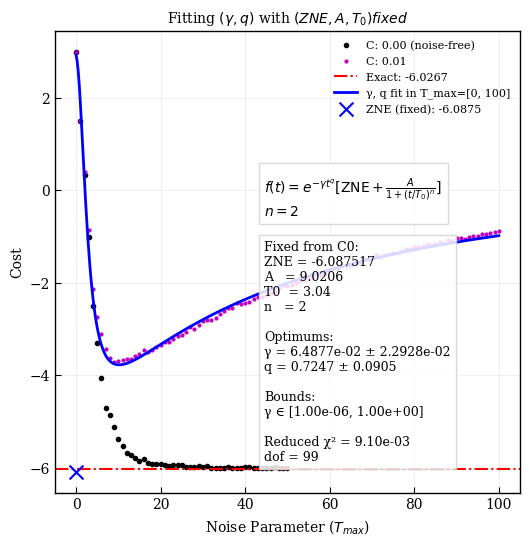

In [33]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---

```Could you calculate
R(T_max, C):= - log (E_noisy(T_max, C)/ E_ideal(T_max) )
If R(T,C1)/R(T,C2) ≈ const(C1,C2)
That is if R(T,C1)/R(T,C2) is almost constant with T,
then, we are seeing something physical
```

In [34]:
# --- C = 0.01 ---
vqe_means_c0_01   = data_records["c0.01"]["processed"]["vqe_means"]
vqe_stds_c0_01    = data_records["c0.01"]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records["c0.01"]["processed"]["t_max"]

# --- C = 0.05 ---
vqe_means_c0_05    = data_records["c0.05"]["processed"]["vqe_means"]
vqe_stds_c0_05    = data_records["c0.05"]["processed"]["vqe_stds"]
noise_levels_c0_05 = data_records["c0.05"]["processed"]["t_max"]

# --- C = 0.1 ---
vqe_means_c0_1     = data_records["c0.1"]["processed"]["vqe_means"]
vqe_stds_c0_1     = data_records["c0.1"]["processed"]["vqe_stds"]
noise_levels_c0_1  = data_records["c0.1"]["processed"]["t_max"]

# --- C = 0.2 ---
vqe_means_c0_2     = data_records["c0.2"]["processed"]["vqe_means"]
vqe_stds_c0_2     = data_records["c0.2"]["processed"]["vqe_stds"]
noise_levels_c0_2  = data_records["c0.2"]["processed"]["t_max"]

# --- C = 0.5 ---
vqe_means_c0_5     = data_records["c0.5"]["processed"]["vqe_means"]
vqe_stds_c0_5     = data_records["c0.5"]["processed"]["vqe_stds"]
noise_levels_c0_5  = data_records["c0.5"]["processed"]["t_max"]


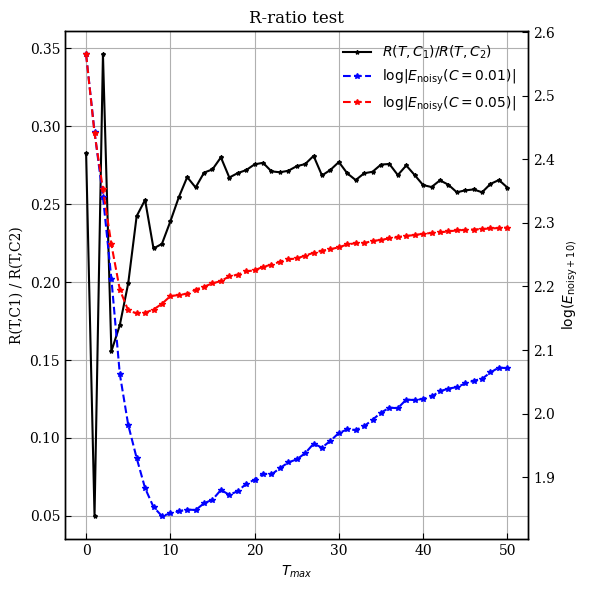

In [35]:
# --- Containers ---
R_ratio_vals = []
E_noisy_c_1 = []
E_noisy_c_2 = []

# --- Main loop (no physics changed) ---
for E_ideal, E_c1, E_c2 in zip(
        vqe_means_c0,
        vqe_means_c0_01,
        vqe_means_c0_05):

    R1 = -np.log(E_c1 / E_ideal)
    R2 = -np.log(E_c2 / E_ideal)

    R_ratio_vals.append(R1 / R2)
    E_noisy_c_1.append(np.log((10+E_c1)))
    E_noisy_c_2.append(np.log((10+E_c2)))

# --- Convert to arrays ---
R_ratio_vals = np.array(R_ratio_vals)
E_noisy_c_1 = np.array(E_noisy_c_1)
E_noisy_c_2 = np.array(E_noisy_c_2)

# --- Fix length mismatch (CRITICAL) ---
N = len(R_ratio_vals)
T_plot = noise_levels_c0[:N]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(6, 6))

# Left axis: R ratio
ax1.plot(
    T_plot,
    R_ratio_vals,
    '*-',
    color='black',
    markersize=3,
    label=r"$R(T,C_1)/R(T,C_2)$"
)
ax1.set_xlabel("$T_{max}$")
ax1.set_ylabel("R(T,C1) / R(T,C2)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True)

# Right axis: log energies
ax2 = ax1.twinx()
ax2.plot(
    T_plot,
    E_noisy_c_1[:N],
    '*--',
    color='blue',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.01)|$"
)

ax2.plot(
    T_plot,
    E_noisy_c_2[:N],
    '*--',
    color='red',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.05)|$"
)

ax2.set_ylabel(r"$\log (E_{\mathrm{noisy} + 10)}$", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# --- Legends (both axes) ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="best")

plt.title("R-ratio test")
plt.tight_layout()
plt.show()


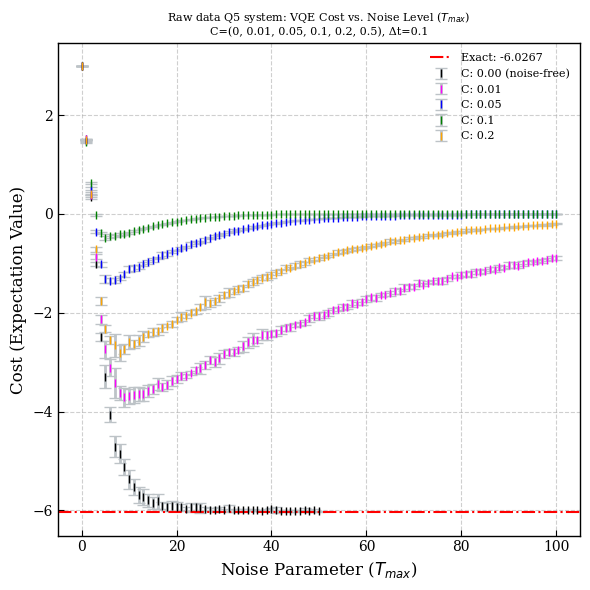

In [36]:
plt.figure(figsize=(6, 6))

# --- Noise-free ---
plt.errorbar(
    noise_levels_c0,
    vqe_means_c0,
    yerr=vqe_stds_c0,
    fmt='|',
    color='black',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.00 (noise-free)'
)

# --- C = 0.01 ---
plt.errorbar(
    noise_levels_c0_01,
    vqe_means_c0_01,
    yerr=vqe_stds_c0_01,
    fmt='|',
    color='magenta',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.01'
)

# --- C = 0.05 ---
plt.errorbar(
    noise_levels_c0_05,
    vqe_means_c0_05,
    yerr=vqe_stds_c0_05,
    fmt='|',
    color='blue',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.05'
)

# --- C = 0.1 ---
plt.errorbar(
    noise_levels_c0_1,
    vqe_means_c0_1,
    yerr=vqe_stds_c0_1,
    fmt='|',
    color='green',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.1'
)

# --- C = 0.2 ---
plt.errorbar(
    noise_levels_c0_2,
    vqe_means_c0_2,
    yerr=vqe_stds_c0_2,
    fmt='|',
    color='orange',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.2'
)


# --- Exact solution line ---
plt.axhline(
    y=EXACT_SOLUTION,
    color='red',
    linestyle='-.',
    label=f'Exact: {EXACT_SOLUTION:.4f}'
)

# --- Aesthetics ---
plt.title(
    "Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$)\n"
    "C=(0, 0.01, 0.05, 0.1, 0.2, 0.5), Δt=0.1",
    fontsize=8
)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [37]:
# Extract T
T = np.array(data_records["c0.01"]["processed"]["t_max"])

# Means
E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
E_c01  = np.array(data_records["c0.1"]["processed"]["vqe_means"])
E_c02  = np.array(data_records["c0.2"]["processed"]["vqe_means"])

# Standard deviations
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c01  = np.array(data_records["c0.1"]["processed"]["vqe_stds"])
std_c02  = np.array(data_records["c0.2"]["processed"]["vqe_stds"])

def print_delta_with_std(E1, E2, std1, label):
    print("\n==============================")
    print(label)
    print("==============================")
    for i in range(len(T)):
        delta_E = E1[i] - E2[i]
        print(
            f"T={T[i]:.4f} | "
            f"ΔE={delta_E:.6e} | "
            f"σ(C1)={std1[i]:.6e}"
        )

# Comparisons (C1 − C2, and σ of C1)
print_delta_with_std(E_c001, E_c005, std_c001, "C=0.01 − C=0.05")
print_delta_with_std(E_c005, E_c01,  std_c005, "C=0.05 − C=0.1")
print_delta_with_std(E_c01,  E_c02,  std_c01,  "C=0.1 − C=0.2")



C=0.01 − C=0.05
T=0.0000 | ΔE=1.822865e-08 | σ(C1)=6.780163e-08
T=1.0000 | ΔE=2.498258e-02 | σ(C1)=8.549300e-03
T=2.0000 | ΔE=-1.220346e-01 | σ(C1)=4.262030e-02
T=3.0000 | ΔE=-5.059148e-01 | σ(C1)=5.004688e-02
T=4.0000 | ΔE=-1.115793e+00 | σ(C1)=8.629454e-02
T=5.0000 | ΔE=-1.432069e+00 | σ(C1)=1.762276e-01
T=6.0000 | ΔE=-1.760677e+00 | σ(C1)=1.791298e-01
T=7.0000 | ΔE=-2.088425e+00 | σ(C1)=3.024837e-01
T=8.0000 | ΔE=-2.323215e+00 | σ(C1)=1.480480e-01
T=9.0000 | ΔE=-2.493267e+00 | σ(C1)=1.943022e-01
T=10.0000 | ΔE=-2.573052e+00 | σ(C1)=1.516316e-01
T=11.0000 | ΔE=-2.567809e+00 | σ(C1)=1.568470e-01
T=12.0000 | ΔE=-2.568786e+00 | σ(C1)=1.431708e-01
T=13.0000 | ΔE=-2.631140e+00 | σ(C1)=1.271287e-01
T=14.0000 | ΔE=-2.605976e+00 | σ(C1)=1.132452e-01
T=15.0000 | ΔE=-2.615080e+00 | σ(C1)=1.052322e-01
T=16.0000 | ΔE=-2.549176e+00 | σ(C1)=1.241302e-01
T=17.0000 | ΔE=-2.666059e+00 | σ(C1)=8.348572e-02
T=18.0000 | ΔE=-2.653686e+00 | σ(C1)=8.933093e-02
T=19.0000 | ΔE=-2.623945e+00 | σ(C1)=1.036259

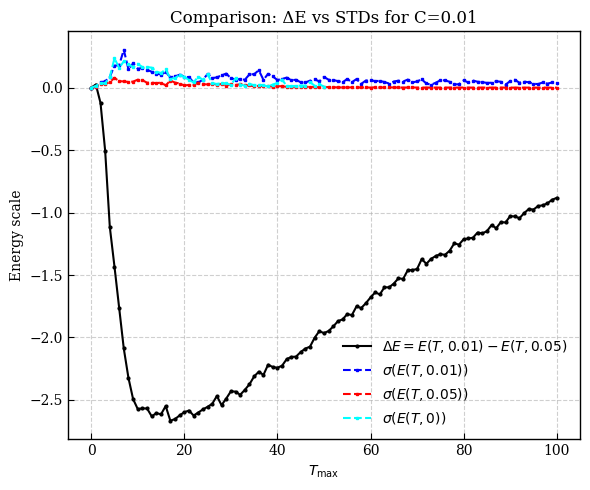

In [38]:
# --- Extract data ---
T = np.array(data_records["c0.01"]["processed"]["t_max"])

E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c0 = np.array(data_records["c0"]["processed"]["vqe_stds"])
T_0 = np.array(data_records["c0"]["processed"]["t_max"])
# --- Compute Delta E ---
delta_E = E_c001 - E_c005

# --- Ensure same length ---
N = min(len(T), len(delta_E), len(std_c001))
T_plot = T[:N]
delta_E = delta_E[:N]
std_c001 = std_c001[:N]

# --- Plot ---
plt.figure(figsize=(6, 5))

plt.plot(
    T_plot,
    delta_E,
    'o-',
    color='black',
    markersize=2,
    label=r'$\Delta E = E(T,0.01) - E(T,0.05)$'
)

plt.plot(
    T_plot,
    std_c001,
    's--',
    color='blue',
    markersize=2,
    label=r'$\sigma(E(T,0.01))$'
)
plt.plot(
    T_plot,
    std_c005,
    's--',
    color='red',
    markersize=2,
    label=r'$\sigma(E(T,0.05))$'
)
plt.plot(
    T_0,
    std_c0,
    's--',
    color='cyan',
    markersize=2,
    label=r'$\sigma(E(T,0))$'
)

plt.xlabel(r"$T_{\max}$")
plt.ylabel("Energy scale")
plt.title("Comparison: ΔE vs STDs for C=0.01")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


---

Polynomial fitting of 
$R(T,C)=F0(T) + C・F1(T)+ C^2 ・F2(T)+C^3・F3(T)$


In [39]:
import numpy as np

# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
poly_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]
E_ideal = vqe_means_c0
E_ideal_cut = E_ideal[mask_start:mask_end]
T_values = noise_levels_c0_01[mask_start:mask_end]

E_c = np.array(E_c_raw)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Polynomial fit in C
# =========================
n_T = len(T_values)
coeffs_T = np.zeros((n_T, poly_degree + 1))

for i in range(n_T):
    y = R[:, i]
    coeffs = np.polyfit(C_values, y, poly_degree)
    coeffs_T[i] = coeffs[::-1]   # [F0, F1, F2, ...]

# =========================
# Print results
# =========================
header = "T"
for k in range(poly_degree + 1):
    header += f"    F{k}(T)"
print(header)

for i, T in enumerate(T_values):
    row = f"{T:.6f}"
    for k in range(poly_degree + 1):
        row += f"    {coeffs_T[i, k]: .6e}"
    print(row)


T    F0(T)    F1(T)    F2(T)    F3(T)
3.000000     4.401211e-01    -4.056836e+01     1.337153e+03    -5.682684e+03
4.000000     3.574668e-02     9.865535e+00     2.079100e+02    -1.247286e+03
5.000000     6.990867e-02     9.334075e+00     2.191455e+02    -1.294247e+03
6.000000     1.337955e-01     1.111326e+01     2.358865e+02    -1.415944e+03
7.000000     1.423225e-01     1.569249e+01     1.987172e+02    -1.332172e+03
8.000000     8.624152e-02     1.892494e+01     1.803660e+02    -1.318061e+03
9.000000     6.252900e-02     2.511395e+01     1.004226e+02    -1.059287e+03
10.000000     7.478775e-02     2.972897e+01     5.127189e+01    -9.181327e+02
11.000000     1.272038e-01     2.757636e+01     1.011755e+02    -1.118390e+03
12.000000     1.646895e-01     2.694707e+01     1.208639e+02    -1.199077e+03
13.000000     1.495400e-01     2.906947e+01     1.078994e+02    -1.180571e+03
14.000000     1.775816e-01     2.933183e+01     1.160028e+02    -1.227312e+03
15.000000     1.890385e-01     3.

Could you changing the degree and see how the remaining square error changes depending on degree.

In [40]:
# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
max_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]

E_ideal_cut = vqe_means_c0[mask_start:mask_end]

E_c = np.array(E_c_raw)  # shape (nC, nT)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Degree scan
# =========================
print("Polynomial degree vs residual error")
print("-----------------------------------")

for deg in range(1, max_degree + 1):
    rss_total = 0.0

    for t_idx in range(R.shape[1]):
        y = R[:, t_idx]

        coeffs = np.polyfit(C_values, y, deg)
        y_fit = np.polyval(coeffs, C_values)

        residuals = y - y_fit
        rss_total += np.sum(residuals**2)

    print(f"Degree {deg}: RSS = {rss_total:.6e}")


Polynomial degree vs residual error
-----------------------------------
Degree 1: RSS = 4.879212e+02
Degree 2: RSS = 1.830214e+01
Degree 3: RSS = 2.675059e-27


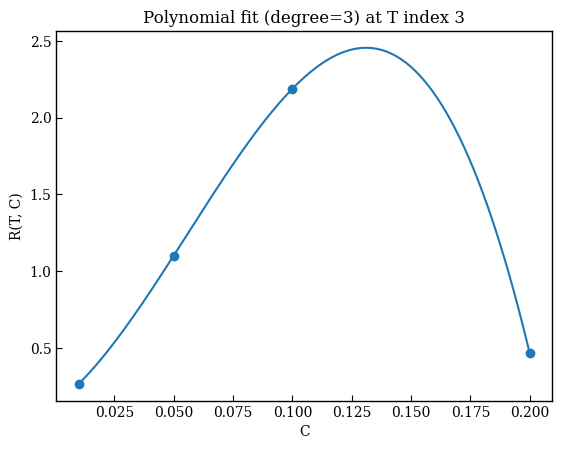

In [41]:
# =========================
# User choice
# =========================
poly_degree = 3
t_index = 3   # choose which T to visualize

# =========================
# Data at selected T
# =========================
y = R[:, t_index]          # R vs C at fixed T
C_vals = C_values

# Polynomial fit
coeffs = np.polyfit(C_vals, y, poly_degree)

# Smooth curve for plotting
C_smooth = np.linspace(min(C_vals), max(C_vals), 200)
y_fit = np.polyval(coeffs, C_smooth)

# =========================
# Plot
# =========================
plt.figure()
plt.scatter(C_vals, y)
plt.plot(C_smooth, y_fit)

plt.xlabel("C")
plt.ylabel("R(T, C)")
plt.title(f"Polynomial fit (degree={poly_degree}) at T index {t_index}")
plt.show()


---

Richardson ZNE

In [42]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_01)
means_arr = np.array(vqe_means_c0_01)

mask = (noise_arr >= 50) & (noise_arr <= 70)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 3
print(f"C = 0.01 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

C = 0.01 | T range: 50.00 to 70.00 | Total points: 21

Window     | Input T [points used]                         | ZNE Value   
-------------------------------------------------------------------------------------
0 to 2     | [50, 51, 52]                                  | 19.905687   
1 to 3     | [51, 52, 53]                                  | -2.151046   
2 to 4     | [52, 53, 54]                                  | -34.370123  
3 to 5     | [53, 54, 55]                                  | 33.306047   
4 to 6     | [54, 55, 56]                                  | -78.780169  
5 to 7     | [55, 56, 57]                                  | 113.411789  
6 to 8     | [56, 57, 58]                                  | -136.481922 
7 to 9     | [57, 58, 59]                                  | 86.384841   
8 to 10    | [58, 59, 60]                                  | 0.602875    
9 to 11    | [59, 60, 61]                                  | -9.290986   
10 to 12   | [60, 61, 62]                    

In [43]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_05)
means_arr = np.array(vqe_means_c0_05)

mask = (noise_arr >= 3) & (noise_arr <= 20)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 2
print(f"C = 0.05 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

C = 0.05 | T range: 3.00 to 20.00 | Total points: 18

Window     | Input T [points used]                         | ZNE Value   
-------------------------------------------------------------------------------------
0 to 1     | [3, 4]                                        | 1.630592    
1 to 2     | [4, 5]                                        | 0.137686    
2 to 3     | [5, 6]                                        | -1.112009   
3 to 4     | [6, 7]                                        | -1.404243   
4 to 5     | [7, 8]                                        | -1.640387   
5 to 6     | [8, 9]                                        | -1.930612   
6 to 7     | [9, 10]                                       | -2.174377   
7 to 8     | [10, 11]                                      | -1.273438   
8 to 9     | [11, 12]                                      | -1.296216   
9 to 10    | [12, 13]                                      | -1.765290   
10 to 11   | [13, 14]                         

---